In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [81]:
import pandas as pd


dates = pd.date_range(start="2026-02-07", end="2026-02-07")

# 拼接所有路径
paths = [
    f"/content/drive/MyDrive/UT Austin/2026 Spring/Sabre/code/data/cleaned_partitioned/date={d.strftime('%Y-%m-%d')}"
    for d in dates
]

df = pd.concat([pd.read_parquet(p) for p in paths], ignore_index=True)

# path = '/content/drive/MyDrive/UT Austin/2026 Spring/Sabre/code/three_month_modified_hourly.parquet'
# df = pd.read_parquet(path)
df.head()

,rq_correlation_id,rq_timestamp,rq_user,rq_group,rq_rate_plan_candidates,rq_hotel_chain_codes,rq_hotel_refs,rq_hotel_name,rq_stay_start_date,rq_stay_end_date,...,chain_code,brand_code,distance,sabre_rating,location_city_code,location_countrycode,location_latitude,location_longitude,convertedrate_infos,hotelrateinfo
0,0e2rk6o86,2026-02-07T13:09:59+0000,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[316762|SABRE,316851|SABRE,31848|SABRE,31880|S...",None,2026-02-09,2026-02-10,...,RU,10341,NaN,2.5,DFW,US,32.92797,-96.997793,"[{'amount_after_tax': 295.27, 'currency_code':...",[]
1,24fcnl18t,2026-02-07T13:19:07+0000,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[193865|SABRE,315612|SABRE,28920|SABRE,55023|S...",None,2026-02-07,2026-02-08,...,HH,15573,NaN,3.5,DFW,US,32.752482,-97.329778,"[{'amount_after_tax': 347.43, 'currency_code':...",[]
2,0e2rk6o86,2026-02-07T13:09:59+0000,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[316762|SABRE,316851|SABRE,31848|SABRE,31880|S...",None,2026-02-09,2026-02-10,...,DT,16007,NaN,4.0,DFW,US,32.916412,-97.007613,"[{'amount_after_tax': 286.35, 'currency_code':...",[]
3,24fcnl18t,2026-02-07T13:19:07+0000,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[193865|SABRE,315612|SABRE,28920|SABRE,55023|S...",None,2026-02-07,2026-02-08,...,SI,15863,NaN,3.0,DFW,US,32.926498,-96.824411,"[{'amount_after_tax': 169.15, 'currency_code':...",[]
4,0e2rk6o86,2026-02-07T13:09:59+0000,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[316762|SABRE,316851|SABRE,31848|SABRE,31880|S...",None,2026-02-09,2026-02-10,...,HY,16327,NaN,3.0,DFW,US,32.903849,-97.312277,"[{'amount_after_tax': 128.47, 'currency_code':...",[]


In [4]:
df.columns

Index(['rq_correlation_id', 'rq_timestamp', 'rq_user', 'rq_group',
       'rq_rate_plan_candidates', 'rq_hotel_chain_codes', 'rq_hotel_refs',
       'rq_hotel_name', 'rq_stay_start_date', 'rq_stay_end_date', 'hotel_code',
       'chain_code', 'brand_code', 'distance', 'sabre_rating',
       'location_city_code', 'location_countrycode', 'location_latitude',
       'location_longitude', 'convertedrate_infos', 'hotelrateinfo'],
      dtype='object')

## Feature Engineering


In [82]:
import pandas as pd

# rq_timestamp 已经是 UTC（直接确保类型对）
df['rq_timestamp'] = pd.to_datetime(df['rq_timestamp'], utc=True)

# 先转 datetime
df['rq_stay_start_date'] = pd.to_datetime(df['rq_stay_start_date'], format = 'mixed')
df['rq_stay_end_date'] = pd.to_datetime(df['rq_stay_end_date'],format = 'mixed')


# NYC
mask_nyc = df['location_city_code'].isin(['JFK', 'EWR', 'LGA', 'NYC'])
df.loc[mask_nyc, 'rq_stay_start_date_utc'] = (
    df.loc[mask_nyc, 'rq_stay_start_date']
      .dt.tz_localize('America/New_York')
      .dt.tz_convert('UTC')
)

df.loc[mask_nyc, 'rq_stay_end_date_utc'] = (
    df.loc[mask_nyc, 'rq_stay_end_date']
      .dt.tz_localize('America/New_York')
      .dt.tz_convert('UTC')
)

# DFW（Dallas）
mask_dfw = df['location_city_code'].isin(['DFW', 'DAL'])
df.loc[mask_dfw, 'rq_stay_start_date_utc'] = (
    df.loc[mask_dfw, 'rq_stay_start_date']
      .dt.tz_localize('America/Chicago')
      .dt.tz_convert('UTC')
)

df.loc[mask_dfw, 'rq_stay_end_date_utc'] = (
    df.loc[mask_dfw, 'rq_stay_end_date']
      .dt.tz_localize('America/Chicago')
      .dt.tz_convert('UTC')
)


# 2. Lead time（单位：天，更常用 & 可解释）
df['lead_time'] = (df['rq_stay_start_date_utc'] - df['rq_timestamp']).dt.days

#if lead_time < 0 convert to 0
df.loc[df['lead_time'] < 0, 'lead_time'] = 0

# 3. Create unique cache_key（全部转string更安全）
df['cache_key'] = (
    df['hotel_code'].astype(str) + '-' +
    df['location_city_code'] + '-' +
    df['rq_stay_start_date'].dt.strftime('%Y-%m-%d') + '-' +
    df['rq_stay_end_date'].dt.strftime('%Y-%m-%d')
)

# 4. Extract hour
df['rq_hour'] = df['rq_timestamp'].dt.hour

# 5. Floor to hour（推荐用 'H' 更清晰）
df['timestamp_hour'] = df['rq_timestamp'].dt.floor('H')

df['duration'] = (df['rq_stay_end_date'] - df['rq_stay_start_date']).dt.days

# 6. Inspect
print(df[['cache_key', 'rq_timestamp', 'rq_hour', 'timestamp_hour', 'lead_time']].head())
print(f'\nNew columns added: {["lead_time", "rq_hour", "timestamp_hour"]}')

                             cache_key              rq_timestamp  rq_hour  \
0  100689593-DFW-2026-02-09-2026-02-10 2026-02-07 13:09:59+00:00       13   
1  100436904-DFW-2026-02-07-2026-02-08 2026-02-07 13:19:07+00:00       13   
2  100213512-DFW-2026-02-09-2026-02-10 2026-02-07 13:09:59+00:00       13   
3  100437096-DFW-2026-02-07-2026-02-08 2026-02-07 13:19:07+00:00       13   
4  102101809-DFW-2026-02-09-2026-02-10 2026-02-07 13:09:59+00:00       13   

             timestamp_hour  lead_time  
0 2026-02-07 13:00:00+00:00          1  
1 2026-02-07 13:00:00+00:00          0  
2 2026-02-07 13:00:00+00:00          1  
3 2026-02-07 13:00:00+00:00          0  
4 2026-02-07 13:00:00+00:00          1  

New columns added: ['lead_time', 'rq_hour', 'timestamp_hour']


/tmp/ipykernel_2236/1821849247.py:58: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['timestamp_hour'] = df['rq_timestamp'].dt.floor('H')


## Assign demand score

In [ ]:
df.columns

Index(['rq_correlation_id', 'rq_timestamp', 'rq_user', 'rq_group',
       'rq_rate_plan_candidates', 'rq_hotel_chain_codes', 'rq_hotel_refs',
       'rq_hotel_name', 'rq_stay_start_date', 'rq_stay_end_date', 'hotel_code',
       'chain_code', 'brand_code', 'distance', 'sabre_rating',
       'location_city_code', 'location_countrycode', 'location_latitude',
       'location_longitude', 'convertedrate_infos', 'hotelrateinfo',
       'rq_stay_start_date_utc', 'rq_stay_end_date_utc', 'lead_time',
       'cache_key', 'rq_hour', 'timestamp_hour'],
      dtype='object')

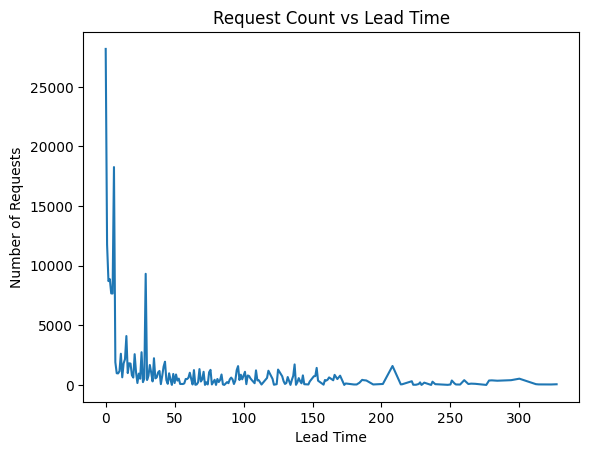

In [ ]:
import pandas as pd

# 假设你的 dataframe 叫 df
lead_counts = df.groupby('lead_time').size().reset_index(name='rq_count')

import matplotlib.pyplot as plt

plt.figure()
plt.plot(lead_counts['lead_time'], lead_counts['rq_count'])

plt.xlabel('Lead Time')
plt.ylabel('Number of Requests')
plt.title('Request Count vs Lead Time')

plt.show()

In [ ]:
df['lead_time_freq'] = pd.cut(
    df['lead_time'],
    bins=[-1,1,3,10,50,100000],
    labels=[1,0.8,0.3,0.1,0.05]
)
df[['lead_time_freq']]


In [ ]:
import numpy as np

def lead_time_weight(x):
    if x <= 50:
        return np.exp(-x / 20)
    else:
        return 0.05  # plateau floor

df['lead_time_weight'] = df['lead_time'].apply(lead_time_weight)

In [ ]:
df

,rq_correlation_id,rq_timestamp,rq_user,rq_group,rq_rate_plan_candidates,rq_hotel_chain_codes,rq_hotel_refs,rq_hotel_name,rq_stay_start_date,rq_stay_end_date,...,hotelrateinfo,rq_stay_start_date_utc,rq_stay_end_date_utc,lead_time,cache_key,rq_hour,timestamp_hour,lead_time_freq,chain_weight,lead_time_weight
0,0e2rk6o86,2026-02-07 13:09:59+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[316762|SABRE,316851|SABRE,31848|SABRE,31880|S...",None,2026-02-09,2026-02-10,...,[],2026-02-09 06:00:00+00:00,2026-02-10 06:00:00+00:00,1,RU-DFW-2026-02-09-2026-02-10,13,2026-02-07 13:00:00+00:00,0.8,0.693428,0.951229
1,24fcnl18t,2026-02-07 13:19:07+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[193865|SABRE,315612|SABRE,28920|SABRE,55023|S...",None,2026-02-07,2026-02-08,...,[],2026-02-07 06:00:00+00:00,2026-02-08 06:00:00+00:00,0,HH-DFW-2026-02-07-2026-02-08,13,2026-02-07 13:00:00+00:00,1.0,0.875293,1.000000
2,0e2rk6o86,2026-02-07 13:09:59+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[316762|SABRE,316851|SABRE,31848|SABRE,31880|S...",None,2026-02-09,2026-02-10,...,[],2026-02-09 06:00:00+00:00,2026-02-10 06:00:00+00:00,1,DT-DFW-2026-02-09-2026-02-10,13,2026-02-07 13:00:00+00:00,0.8,0.863233,0.951229
3,24fcnl18t,2026-02-07 13:19:07+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[193865|SABRE,315612|SABRE,28920|SABRE,55023|S...",None,2026-02-07,2026-02-08,...,[],2026-02-07 06:00:00+00:00,2026-02-08 06:00:00+00:00,0,SI-DFW-2026-02-07-2026-02-08,13,2026-02-07 13:00:00+00:00,1.0,0.811911,1.000000
4,0e2rk6o86,2026-02-07 13:09:59+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[316762|SABRE,316851|SABRE,31848|SABRE,31880|S...",None,2026-02-09,2026-02-10,...,[],2026-02-09 06:00:00+00:00,2026-02-10 06:00:00+00:00,1,HY-DFW-2026-02-09-2026-02-10,13,2026-02-07 13:00:00+00:00,0.8,1.000000,0.951229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203629,2matifsis,2026-02-07 12:29:46+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[18e02aae6afcbad332e5c419b2e3a40d02a3d1dc7bb0a...,[],"[4690|SABRE,56058|SABRE,58294|SABRE,314405|SAB...",None,2026-02-08,2026-02-09,...,[],2026-02-08 05:00:00+00:00,2026-02-09 05:00:00+00:00,0,YX-LGA-2026-02-08-2026-02-09,12,2026-02-07 12:00:00+00:00,1.0,0.978550,1.000000
203630,2matifsis,2026-02-07 12:29:46+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[18e02aae6afcbad332e5c419b2e3a40d02a3d1dc7bb0a...,[],"[4690|SABRE,56058|SABRE,58294|SABRE,314405|SAB...",None,2026-02-08,2026-02-09,...,[],2026-02-08 05:00:00+00:00,2026-02-09 05:00:00+00:00,0,HY-LGA-2026-02-08-2026-02-09,12,2026-02-07 12:00:00+00:00,1.0,1.000000,1.000000
203631,2matifsis,2026-02-07 12:29:46+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[18e02aae6afcbad332e5c419b2e3a40d02a3d1dc7bb0a...,[],"[4690|SABRE,56058|SABRE,58294|SABRE,314405|SAB...",None,2026-02-08,2026-02-09,...,[],2026-02-08 05:00:00+00:00,2026-02-09 05:00:00+00:00,0,XT-LGA-2026-02-08-2026-02-09,12,2026-02-07 12:00:00+00:00,1.0,0.754691,1.000000
203632,2matifsis,2026-02-07 12:29:46+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[18e02aae6afcbad332e5c419b2e3a40d02a3d1dc7bb0a...,[],"[4690|SABRE,56058|SABRE,58294|SABRE,314405|SAB...",None,2026-02-08,2026-02-09,...,[],2026-02-08 05:00:00

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 转成数值（错误的会变成 NaN）
df['location_latitude'] = pd.to_numeric(df['location_latitude'], errors='coerce')
df['location_longitude'] = pd.to_numeric(df['location_longitude'], errors='coerce')

# 去掉无效数据
df = df.dropna(subset=['location_latitude', 'location_longitude'])


import plotly.express as px

agg = df.groupby(['location_latitude', 'location_longitude']).size().reset_index(name='rq_count')

fig = px.scatter_mapbox(
    agg,
    lat="location_latitude",
    lon="location_longitude",
    size="rq_count",
    size_max=15,
    zoom=3
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

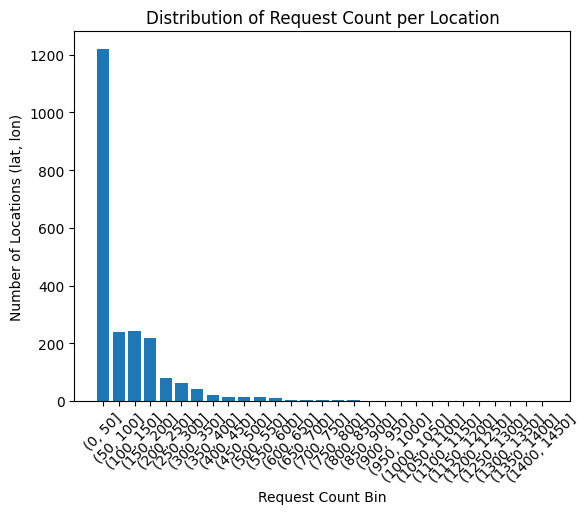

In [ ]:
bins = list(range(0, agg['rq_count'].max() + 50, 50))
agg['rq_bin'] = pd.cut(agg['rq_count'], bins=bins)

# 4️⃣ 统计每个bin里有多少个 location
bin_counts = agg['rq_bin'].value_counts().sort_index()

# 5️⃣ 画 bar 图
plt.figure()
plt.bar(bin_counts.index.astype(str), bin_counts.values)

plt.xlabel('Request Count Bin')
plt.ylabel('Number of Locations (lat, lon)')
plt.title('Distribution of Request Count per Location')

plt.xticks(rotation=45)
plt.show()

<Figure size 640x480 with 0 Axes>

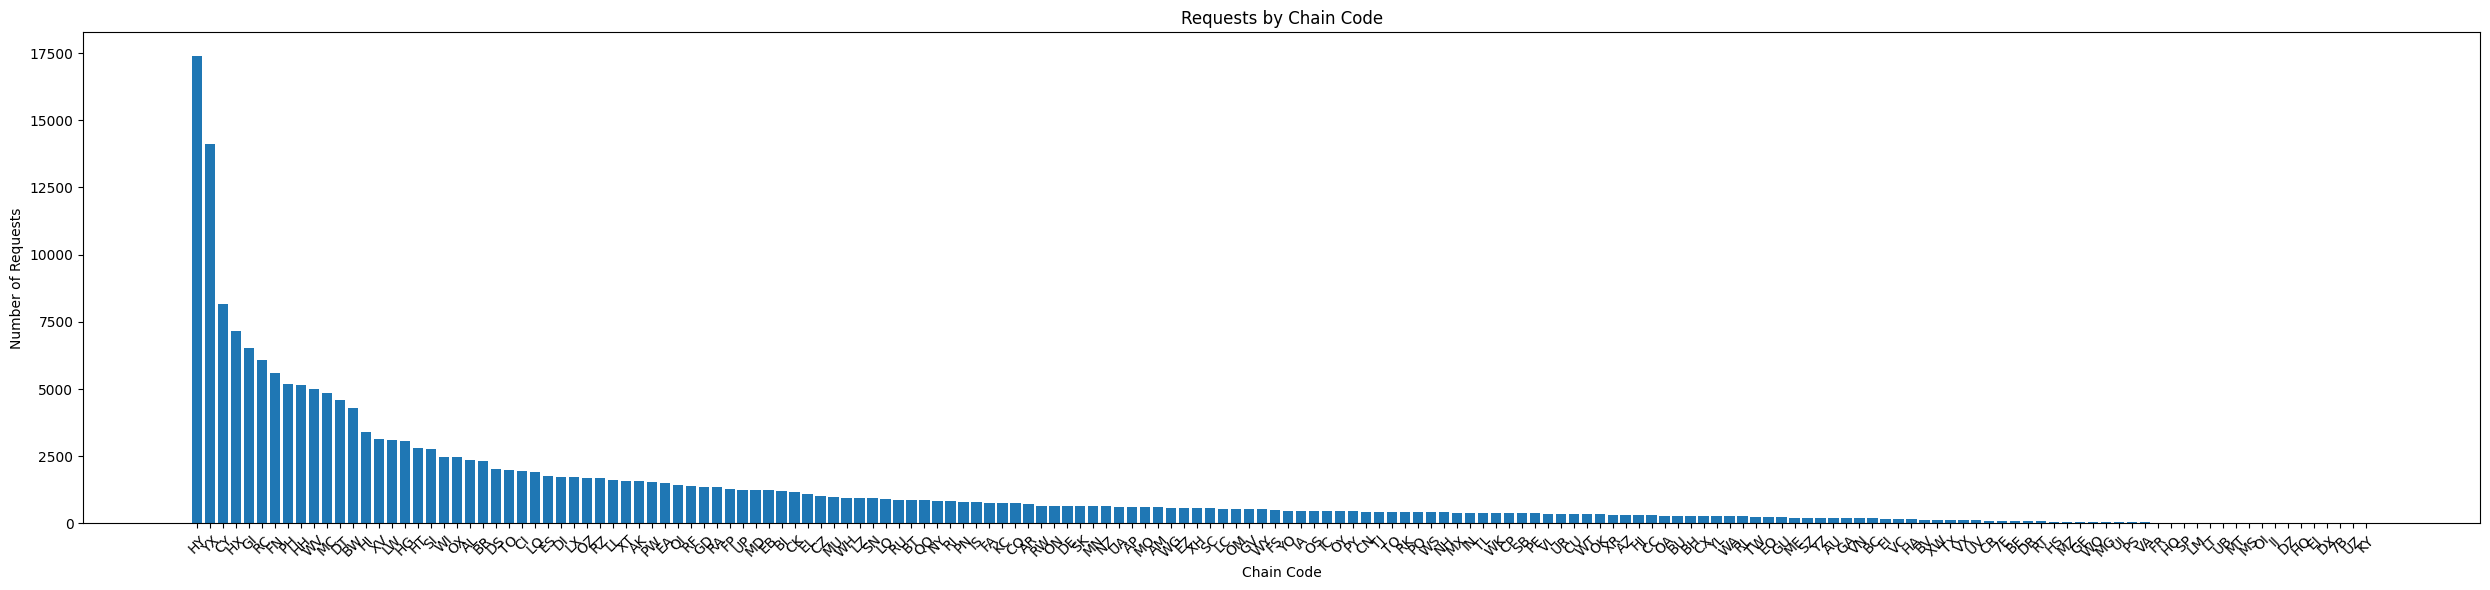

In [ ]:
import matplotlib.pyplot as plt

# 统计每个 chain_code 的 request 数量
chain_counts = df['chain_code'].value_counts().reset_index()
chain_counts.columns = ['chain_code', 'rq_count']

# 画 bar chart
plt.figure()
plt.figure(figsize=(20,6))
plt.bar(chain_counts['chain_code'], chain_counts['rq_count'])

plt.xlabel('Chain Code')
plt.ylabel('Number of Requests')
plt.title('Requests by Chain Code')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

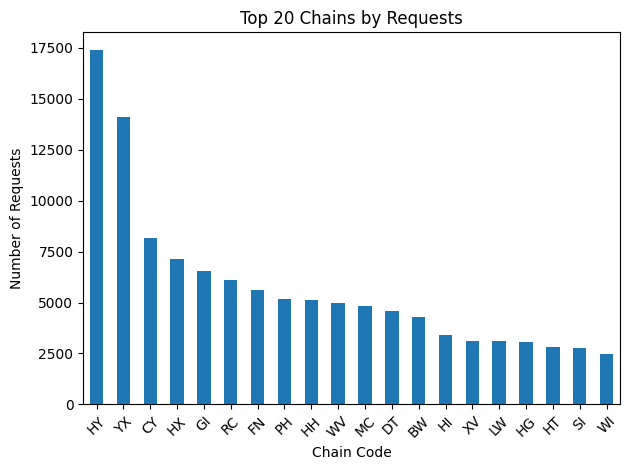

In [ ]:
top_n = 20
chain_counts = df['chain_code'].value_counts().head(top_n)

plt.figure()
chain_counts.plot(kind='bar')

plt.xlabel('Chain Code')
plt.ylabel('Number of Requests')
plt.title(f'Top {top_n} Chains by Requests')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

chain_counts = df['chain_code'].value_counts()

# log scaling + normalization
chain_score = np.log1p(chain_counts)
chain_score = chain_score / chain_score.max()

# map回df
df['chain_weight'] = df['chain_code'].map(chain_score)

In [ ]:
df

,rq_correlation_id,rq_timestamp,rq_user,rq_group,rq_rate_plan_candidates,rq_hotel_chain_codes,rq_hotel_refs,rq_hotel_name,rq_stay_start_date,rq_stay_end_date,...,convertedrate_infos,hotelrateinfo,rq_stay_start_date_utc,rq_stay_end_date_utc,lead_time,cache_key,rq_hour,timestamp_hour,lead_time_freq,chain_weight
0,0e2rk6o86,2026-02-07 13:09:59+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[316762|SABRE,316851|SABRE,31848|SABRE,31880|S...",None,2026-02-09,2026-02-10,...,"[{'amount_after_tax': 295.27, 'currency_code':...",[],2026-02-09 06:00:00+00:00,2026-02-10 06:00:00+00:00,1,RU-DFW-2026-02-09-2026-02-10,13,2026-02-07 13:00:00+00:00,0.8,0.693428
1,24fcnl18t,2026-02-07 13:19:07+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[193865|SABRE,315612|SABRE,28920|SABRE,55023|S...",None,2026-02-07,2026-02-08,...,"[{'amount_after_tax': 347.43, 'currency_code':...",[],2026-02-07 06:00:00+00:00,2026-02-08 06:00:00+00:00,0,HH-DFW-2026-02-07-2026-02-08,13,2026-02-07 13:00:00+00:00,1.0,0.875293
2,0e2rk6o86,2026-02-07 13:09:59+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[316762|SABRE,316851|SABRE,31848|SABRE,31880|S...",None,2026-02-09,2026-02-10,...,"[{'amount_after_tax': 286.35, 'currency_code':...",[],2026-02-09 06:00:00+00:00,2026-02-10 06:00:00+00:00,1,DT-DFW-2026-02-09-2026-02-10,13,2026-02-07 13:00:00+00:00,0.8,0.863233
3,24fcnl18t,2026-02-07 13:19:07+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[193865|SABRE,315612|SABRE,28920|SABRE,55023|S...",None,2026-02-07,2026-02-08,...,"[{'amount_after_tax': 169.15, 'currency_code':...",[],2026-02-07 06:00:00+00:00,2026-02-08 06:00:00+00:00,0,SI-DFW-2026-02-07-2026-02-08,13,2026-02-07 13:00:00+00:00,1.0,0.811911
4,0e2rk6o86,2026-02-07 13:09:59+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[316762|SABRE,316851|SABRE,31848|SABRE,31880|S...",None,2026-02-09,2026-02-10,...,"[{'amount_after_tax': 128.47, 'currency_code':...",[],2026-02-09 06:00:00+00:00,2026-02-10 06:00:00+00:00,1,HY-DFW-2026-02-09-2026-02-10,13,2026-02-07 13:00:00+00:00,0.8,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203629,2matifsis,2026-02-07 12:29:46+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[18e02aae6afcbad332e5c419b2e3a40d02a3d1dc7bb0a...,[],"[4690|SABRE,56058|SABRE,58294|SABRE,314405|SAB...",None,2026-02-08,2026-02-09,...,"[{'amount_after_tax': 219.23, 'currency_code':...",[],2026-02-08 05:00:00+00:00,2026-02-09 05:00:00+00:00,0,YX-LGA-2026-02-08-2026-02-09,12,2026-02-07 12:00:00+00:00,1.0,0.978550
203630,2matifsis,2026-02-07 12:29:46+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[18e02aae6afcbad332e5c419b2e3a40d02a3d1dc7bb0a...,[],"[4690|SABRE,56058|SABRE,58294|SABRE,314405|SAB...",None,2026-02-08,2026-02-09,...,"[{'amount_after_tax': 789.12, 'currency_code':...",[],2026-02-08 05:00:00+00:00,2026-02-09 05:00:00+00:00,0,HY-LGA-2026-02-08-2026-02-09,12,2026-02-07 12:00:00+00:00,1.0,1.000000
203631,2matifsis,2026-02-07 12:29:46+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[18e02aae6afcbad332e5c419b2e3a40d02a3d1dc7bb0a...,[],"[4690|SABRE,56058|SABRE,58294|SABRE,314405|SAB...",None,2026-02-08,2026-02-09,...,"[{'amount_after_tax': 165.47, 'currency_code':...",[],2026-02-08 05:00:00+00:00,2026-02-09 05:00:00+00:00,0,XT-LGA-2026-02-08-2026-02

duration
1      125072
2       29311
3       15989
4       13111
5       11919
6        1526
7        3108
8         665
9          89
10          9
11          1
12         46
15       1231
16         40
17        174
18        170
19         54
20        468
28         88
30         22
31        155
33        180
68         63
96        129
135        14
Name: count, dtype: int64


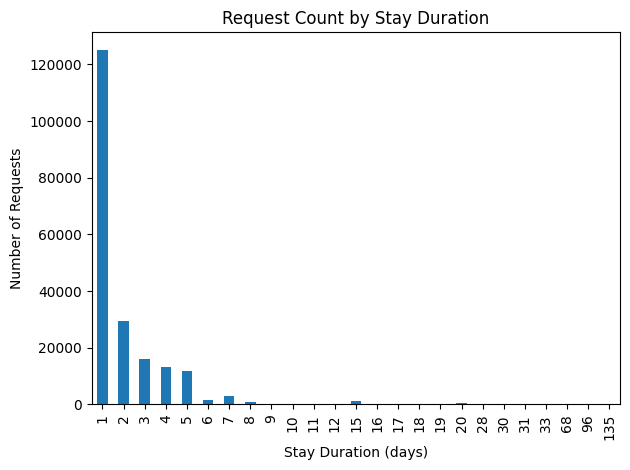

In [ ]:
# 确保是 datetime
df['rq_stay_start_date'] = pd.to_datetime(df['rq_stay_start_date'])
df['rq_stay_end_date'] = pd.to_datetime(df['rq_stay_end_date'])

# 计算 stay duration（单位：天）
df['duration'] = (df['rq_stay_end_date'] - df['rq_stay_start_date']).dt.days

duration_counts = df['duration'].value_counts().sort_index()

print(duration_counts)

import matplotlib.pyplot as plt

plt.figure()
duration_counts.plot(kind='bar')

plt.xlabel('Stay Duration (days)')
plt.ylabel('Number of Requests')
plt.title('Request Count by Stay Duration')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

duration_counts = df['duration'].value_counts()

duration_weight = np.log1p(duration_counts)
duration_weight = duration_weight / duration_weight.max()

df['duration_weight'] = df['duration'].map(duration_weight)

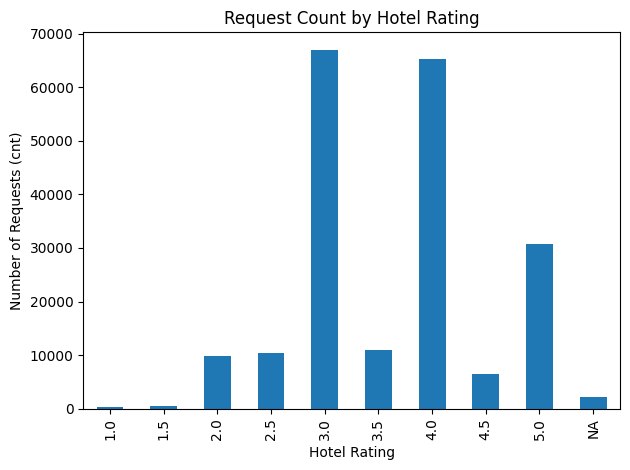

In [ ]:
rating_counts = df['sabre_rating'].value_counts().sort_index()
import matplotlib.pyplot as plt

plt.figure()
rating_counts.plot(kind='bar')

plt.xlabel('Hotel Rating')
plt.ylabel('Number of Requests (cnt)')
plt.title('Request Count by Hotel Rating')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

rating_counts = df['sabre_rating'].value_counts()

# log scaling
rating_weight = np.log1p(rating_counts)
rating_weight = rating_weight / rating_weight.max()

df['rating_weight'] = df['sabre_rating'].map(rating_weight)

In [ ]:
df[['sabre_rating', 'rating_weight']]

,sabre_rating,rating_weight
0,2.5,0.832383
1,3.5,0.837083
2,4.0,0.997818
3,3.0,1.000000
4,3.0,1.000000
...,...,...
203629,3.0,1.000000
203630,5.0,0.929942
203631,4.0,0.997818
203632,4.0,0.997818


In [ ]:
df.columns

Index(['rq_correlation_id', 'rq_timestamp', 'rq_user', 'rq_group',
       'rq_rate_plan_candidates', 'rq_hotel_chain_codes', 'rq_hotel_refs',
       'rq_hotel_name', 'rq_stay_start_date', 'rq_stay_end_date', 'hotel_code',
       'chain_code', 'brand_code', 'distance', 'sabre_rating',
       'location_city_code', 'location_countrycode', 'location_latitude',
       'location_longitude', 'convertedrate_infos', 'hotelrateinfo',
       'rq_stay_start_date_utc', 'rq_stay_end_date_utc', 'lead_time',
       'cache_key', 'rq_hour', 'timestamp_hour', 'lead_time_freq',
       'chain_weight', 'lead_time_weight', 'duration', 'duration_weight',
       'rating_weight'],
      dtype='object')

In [ ]:
df['demand_score'] = df['chain_weight'] * df['duration_weight'] * df['lead_time_weight'] * df['rating_weight']

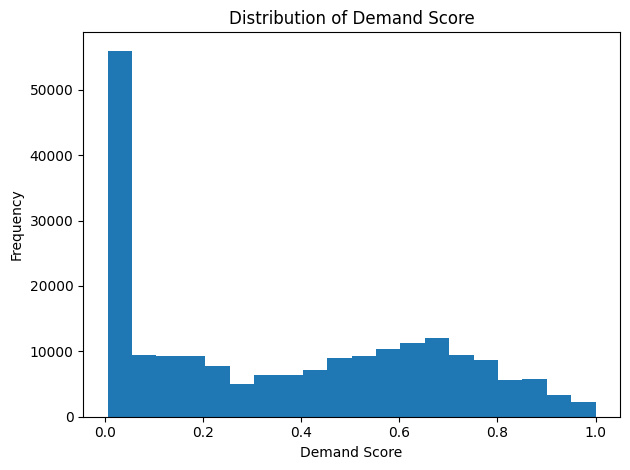

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['demand_score'].dropna(), bins=20)

plt.xlabel('Demand Score')
plt.ylabel('Frequency')
plt.title('Distribution of Demand Score')

plt.tight_layout()
plt.show()

## Stale rate

In [83]:
import re
import hashlib
def make_rate_group(val):

    if pd.isna(val) or str(val).strip() in ('[]', '', 'nan'):
        return 'NO_RATE'
    tokens = re.findall(r'[a-f0-9]{10,}', str(val))
    if not tokens:
        return 'NO_RATE'
    key = '_'.join(sorted(tokens))
    return hashlib.md5(key.encode()).hexdigest()[:12]

df['rate_group']   = df['rq_rate_plan_candidates'].apply(make_rate_group)

In [92]:
df.iloc[150] #5533756713886612290 #101045132-DFW-2026-02-22-2026-02-25

,150
rq_correlation_id,5533756713886612290
rq_timestamp,2026-02-07 19:49:54+00:00
rq_user,90825aa2631e6f784765afc3840338b0393b76f64db8c7...
rq_group,e2748d8d26938d4bc1b53781ddf03d4a2e388e4ccac5be...
rq_rate_plan_candidates,[e58711fc4ef4b389e07d5b2ad06af5dc2187abea74470...
rq_hotel_chain_codes,[]
rq_hotel_refs,[]
rq_hotel_name,None
rq_stay_start_date,2026-02-22 00:00:00
rq_stay_end_date,2026-02-25 00:00:00


In [93]:
import numpy as np
import pandas as pd

def preprocess_convertedrate_infos(v):
    # 每条 entry 内先处理：完全重复去重；同 rate_source 保留最低价
    if isinstance(v, np.ndarray):
        records = v.tolist()
    elif isinstance(v, list):
        records = v
    else:
        return []

    best_by_source = {}
    seen_exact = set()

    for item in records:
        if not isinstance(item, dict):
            continue

        src = item.get('rate_source')
        ccy = item.get('currency_code')
        amt = item.get('amount_after_tax')

        try:
            amt = float(amt)
        except (TypeError, ValueError):
            continue

        exact_key = (src, ccy, amt)
        if exact_key in seen_exact:
            continue
        seen_exact.add(exact_key)

        # 按 source 取最低价；保留该最低价对应的币种
        if src not in best_by_source or amt < best_by_source[src]['amount_after_tax']:
            best_by_source[src] = {
                'amount_after_tax': amt,
                'currency_code': ccy,
                'rate_source': src,
            }

    return list(best_by_source.values())

# 1) 每条 entry 先处理好 convertedrate_infos
df['convertedrate_infos'] = df['convertedrate_infos'].map(preprocess_convertedrate_infos)

# 2) 最后再 explode
df = df.explode('convertedrate_infos', ignore_index=True)
df = df[df['convertedrate_infos'].notna()].copy()

# 3) 展开字段
df['price'] = df['convertedrate_infos'].map(lambda x: x.get('amount_after_tax') if isinstance(x, dict) else np.nan)
df['currencies'] = df['convertedrate_infos'].map(lambda x: x.get('currency_code') if isinstance(x, dict) else None)
df['rate_source'] = df['convertedrate_infos'].map(lambda x: x.get('rate_source') if isinstance(x, dict) else None)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# 4) 汇率映射
fx_to_usd = {
    'USD': 1.0,
    'EUR': 1.08,
    'GBP': 1.27,
    'CAD': 0.74,
    'AUD': 0.66,
    'JPY': 0.0067,
    'CNY': 0.14,
    'HKD': 0.13,
    'TWD': 0.031,
    'KRW': 0.00075,
    'INR': 0.012,
    'BRL': 0.20,
    'MXN': 0.058,
    'COP': 0.00025,
    'ZAR': 0.053,
    'TRY': 0.031,
    'LKR': 0.0033,
}

df['price_in_USD'] = df['price'] * df['currencies'].map(fx_to_usd)
df['price_per_day'] = df['price_in_USD'] / df['duration']
df

,rq_correlation_id,rq_timestamp,rq_user,rq_group,rq_rate_plan_candidates,rq_hotel_chain_codes,rq_hotel_refs,rq_hotel_name,rq_stay_start_date,rq_stay_end_date,...,cache_key,rq_hour,timestamp_hour,duration,rate_group,price,currencies,rate_source,price_in_USD,price_per_day
0,0e2rk6o86,2026-02-07 13:09:59+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[316762|SABRE,316851|SABRE,31848|SABRE,31880|S...",None,2026-02-09,2026-02-10,...,100689593-DFW-2026-02-09-2026-02-10,13,2026-02-07 13:00:00+00:00,1,a024bdc63eee,295.27,USD,100,295.27,295.27
1,24fcnl18t,2026-02-07 13:19:07+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[193865|SABRE,315612|SABRE,28920|SABRE,55023|S...",None,2026-02-07,2026-02-08,...,100436904-DFW-2026-02-07-2026-02-08,13,2026-02-07 13:00:00+00:00,1,a024bdc63eee,347.43,USD,100,347.43,347.43
2,0e2rk6o86,2026-02-07 13:09:59+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[316762|SABRE,316851|SABRE,31848|SABRE,31880|S...",None,2026-02-09,2026-02-10,...,100213512-DFW-2026-02-09-2026-02-10,13,2026-02-07 13:00:00+00:00,1,a024bdc63eee,286.35,USD,100,286.35,286.35
3,24fcnl18t,2026-02-07 13:19:07+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[193865|SABRE,315612|SABRE,28920|SABRE,55023|S...",None,2026-02-07,2026-02-08,...,100437096-DFW-2026-02-07-2026-02-08,13,2026-02-07 13:00:00+00:00,1,a024bdc63eee,169.15,USD,100,169.15,169.15
4,0e2rk6o86,2026-02-07 13:09:59+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[c74a378c0906353a5de6b567f6f11e807d40cfb3e8446...,[],"[316762|SABRE,316851|SABRE,31848|SABRE,31880|S...",None,2026-02-09,2026-02-10,...,102101809-DFW-2026-02-09-2026-02-10,13,2026-02-07 13:00:00+00:00,1,a024bdc63eee,128.47,USD,100,128.47,128.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215821,2matifsis,2026-02-07 12:29:46+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[18e02aae6afcbad332e5c419b2e3a40d02a3d1dc7bb0a...,[],"[4690|SABRE,56058|SABRE,58294|SABRE,314405|SAB...",None,2026-02-08,2026-02-09,...,100032478-LGA-2026-02-08-2026-02-09,12,2026-02-07 12:00:00+00:00,1,8fbad605b1f1,219.23,USD,100,219.23,219.23
215822,2matifsis,2026-02-07 12:29:46+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[18e02aae6afcbad332e5c419b2e3a40d02a3d1dc7bb0a...,[],"[4690|SABRE,56058|SABRE,58294|SABRE,314405|SAB...",None,2026-02-08,2026-02-09,...,100080536-LGA-2026-02-08-2026-02-09,12,2026-02-07 12:00:00+00:00,1,8fbad605b1f1,789.12,USD,100,789.12,789.12
215823,2matifsis,2026-02-07 12:29:46+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[18e02aae6afcbad332e5c419b2e3a40d02a3d1dc7bb0a...,[],"[4690|SABRE,56058|SABRE,58294|SABRE,314405|SAB...",None,2026-02-08,2026-02-09,...,100352340-LGA-2026-02-08-2026-02-09,12,2026-02-07 12:00:00+00:00,1,8fbad605b1f1,165.47,USD,100,165.47,165.47
215824,2matifsis,2026-02-07 12:29:46+00:00,fb4ee5f242ecc75e4ec91ad7066d7cf9d77aa2c868db45...,a5ac5505fd3e8b44a3edb0a3f20cac87aed36009bb9f83...,[18e02aae6afcbad332e5c419b2e3a40d02a3d1dc7bb0a...,[],"[4690|SABRE,56058|SABRE,58294|SABRE,314405|SAB...",None,2026-02-08,2026-02-09,...,100397822-JFK-2026-02-08-2026-02-09,12,2026-02-07 12:00:00+00:00,1,8fbad605b1f1,261.70,USD,100,261.70,261.70


In [94]:
df[df['rq_correlation_id']=='5533756713886612290']

,rq_correlation_id,rq_timestamp,rq_user,rq_group,rq_rate_plan_candidates,rq_hotel_chain_codes,rq_hotel_refs,rq_hotel_name,rq_stay_start_date,rq_stay_end_date,...,cache_key,rq_hour,timestamp_hour,duration,rate_group,price,currencies,rate_source,price_in_USD,price_per_day
150,5533756713886612290,2026-02-07 19:49:54+00:00,90825aa2631e6f784765afc3840338b0393b76f64db8c7...,e2748d8d26938d4bc1b53781ddf03d4a2e388e4ccac5be...,[e58711fc4ef4b389e07d5b2ad06af5dc2187abea74470...,[],[],None,2026-02-22,2026-02-25,...,101045132-DFW-2026-02-22-2026-02-25,19,2026-02-07 19:00:00+00:00,3,9a566b67681b,1537.23,USD,100,1537.23,512.410000
151,5533756713886612290,2026-02-07 19:49:54+00:00,90825aa2631e6f784765afc3840338b0393b76f64db8c7...,e2748d8d26938d4bc1b53781ddf03d4a2e388e4ccac5be...,[e58711fc4ef4b389e07d5b2ad06af5dc2187abea74470...,[],[],None,2026-02-22,2026-02-25,...,101045132-DFW-2026-02-22-2026-02-25,19,2026-02-07 19:00:00+00:00,3,9a566b67681b,1387.59,USD,110,1387.59,462.530000
153,5533756713886612290,2026-02-07 19:49:54+00:00,90825aa2631e6f784765afc3840338b0393b76f64db8c7...,e2748d8d26938d4bc1b53781ddf03d4a2e388e4ccac5be...,[e58711fc4ef4b389e07d5b2ad06af5dc2187abea74470...,[],[],None,2026-02-22,2026-02-25,...,101172225-DAL-2026-02-22-2026-02-25,19,2026-02-07 19:00:00+00:00,3,9a566b67681b,1406.56,USD,100,1406.56,468.853333
154,5533756713886612290,2026-02-07 19:49:54+00:00,90825aa2631e6f784765afc3840338b0393b76f64db8c7...,e2748d8d26938d4bc1b53781ddf03d4a2e388e4ccac5be...,[e58711fc4ef4b389e07d5b2ad06af5dc2187abea74470...,[],[],None,2026-02-22,2026-02-25,...,101172225-DAL-2026-02-22-2026-02-25,19,2026-02-07 19:00:00+00:00,3,9a566b67681b,1324.30,USD,110,1324.30,441.433333
155,5533756713886612290,2026-02-07 19:49:54+00:00,90825aa2631e6f784765afc3840338b0393b76f64db8c7...,e2748d8d26938d4bc1b53781ddf03d4a2e388e4ccac5be...,[e58711fc4ef4b389e07d5b2ad06af5dc2187abea74470...,[],[],None,2026-02-22,2026-02-25,...,101093648-DFW-2026-02-22-2026-02-25,19,2026-02-07 19:00:00+00:00,3,9a566b67681b,858.48,USD,100,858.48,286.160000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,5533756713886612290,2026-02-07 19:49:54+00:00,90825aa2631e6f784765afc3840338b0393b76f64db8c7...,e2748d8d26938d4bc1b53781ddf03d4a2e388e4ccac5be...,[e58711fc4ef4b389e07d5b2ad06af5dc2187abea74470...,[],[],None,2026-02-22,2026-02-25,...,100416550-DFW-2026-02-22-2026-02-25,19,2026-02-07 19:00:00+00:00,3,9a566b67681b,1611.70,USD,110,1611.70,537.233333
218,5533756713886612290,2026-02-07 19:49:54+00:00,90825aa2631e6f784765afc3840338b0393b76f64db8c7...,e2748d8d26938d4bc1b53781ddf03d4a2e388e4ccac5be...,[e58711fc4ef4b389e07d5b2ad06af5dc2187abea74470...,[],[],None,2026-02-22,2026-02-25,...,100094264-DFW-2026-02-22-2026-02-25,19,2026-02-07 19:00:00+00:00,3,9a566b67681b,545.25,USD,100,545.25,181.750000
219,5533756713886612290,2026-02-07 19:49:54+00:00,90825aa2631e6f784765afc3840338b0393b76f64db8c7...,e2748d8d26938d4bc1b53781ddf03d4a2e388e4ccac5be...,[e58711fc4ef4b389e07d5b2ad06af5dc2187abea74470...,[],[],None,2026-02-22,2026-02-25,...,100094264-DFW-2026-02-22-2026-02-25,19,2026-02-07 19:00:00+00:00,3,9a566b67681b,545.44,USD,110,545.44,181.813333
220,5533756713886612290,2026-02-07 19:49:54+00:00,90825aa2631e6f784765afc3840338b0393b76f64db8c7...,e2748d8d26938d4bc1b53781ddf03d4a2e388e4ccac5be...,[e58711fc4ef4b389e07d5b2ad06af5dc2187abea74470...,[],[],None,2026-02-22,2026-02-25,...,100158962-DFW-2026-02-22-2026-02-25,19,2026-02-07 19:00:00+00:00,3,9a566b67681b,1233.62,USD,100,1233.62,411.206667


In [95]:
# df['market_key'] = (
#     df['location_latitude'].astype(str) + '_' +
#     df['location_longitude'].astype(str)
# )

df = df.sort_values(['hotel_code', 'lead_time','rq_timestamp'])

df['price_change'] = (
    df.groupby(['hotel_code','lead_time','rate_source'])['price_per_day']
      .transform(lambda x: (np.abs(x - x.shift()) > 1))
      .fillna(False)
      .astype(int)
)

In [96]:
df[(df['hotel_code'] == '100689593') & (df['rate_group']=='dc481991b526')][['cache_key','rq_correlation_id','lead_time','rq_timestamp','price_change','duration','rate_source','price_per_day']]

,cache_key,rq_correlation_id,lead_time,rq_timestamp,price_change,duration,rate_source,price_per_day
13327,100689593-DFW-2026-02-08-2026-02-09,1qo3pewxt,0,2026-02-07 07:15:58+00:00,0,1,100,112.870000
1908,100689593-DFW-2026-02-07-2026-02-09,21q33k894,0,2026-02-07 07:44:30+00:00,0,2,100,112.860000
49300,100689593-DFW-2026-02-07-2026-02-08,jpq6u9cy1,0,2026-02-07 19:46:52+00:00,1,1,100,112.870000
10143,100689593-DFW-2026-02-08-2026-02-09,wln83raw3,0,2026-02-07 19:59:35+00:00,0,1,100,112.870000
39098,100689593-DFW-2026-02-08-2026-02-09,s1qaikoyo,0,2026-02-07 20:00:35+00:00,0,1,100,112.870000
13914,100689593-DFW-2026-02-08-2026-02-09,dytnnfe77,0,2026-02-07 20:01:29+00:00,0,1,100,112.870000
5092,100689593-DFW-2026-02-08-2026-02-09,axn8o8q3z,0,2026-02-07 20:06:24+00:00,0,1,100,112.870000
29561,100689593-DFW-2026-02-13-2026-02-15,2bel65k5z,5,2026-02-07 14:26:37+00:00,1,2,100,139.345000
18607,100689593-DFW-2026-02-13-2026-02-14,16raepej6,6,2026-02-07 05:01:08+00:00,0,1,100,111.780000
16334,100689593-DFW-2026-02-14-2026-02-15,lyfccwfej,6,2026-02-07 14:27:36+00:00,1,1,100,104.120000


In [ ]:
# easy lambda
import numpy as np

rq_count = df.groupby('chain_code').size()
df['rq_count_chain'] = df['chain_code'].map(rq_count)

df['lambda'] = np.log1p(df['rq_count_chain'])
df['lambda'] = df['lambda'] / df['lambda'].max()

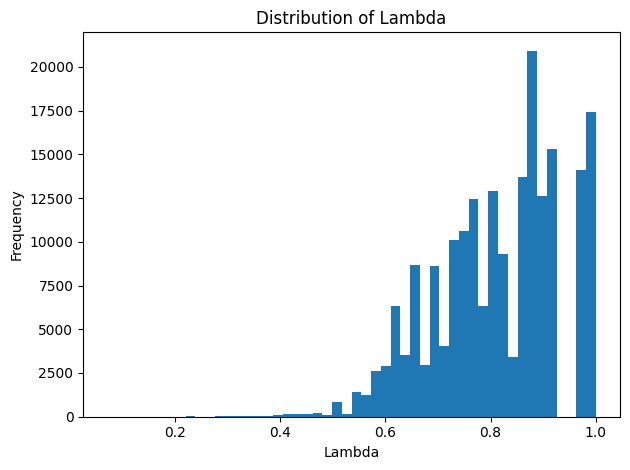

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['lambda'].dropna(), bins=50)

plt.xlabel('Lambda')
plt.ylabel('Frequency')
plt.title('Distribution of Lambda')

plt.tight_layout()
plt.show()

In [ ]:
df['admission_score'] = df['demand_score']/df['lambda']

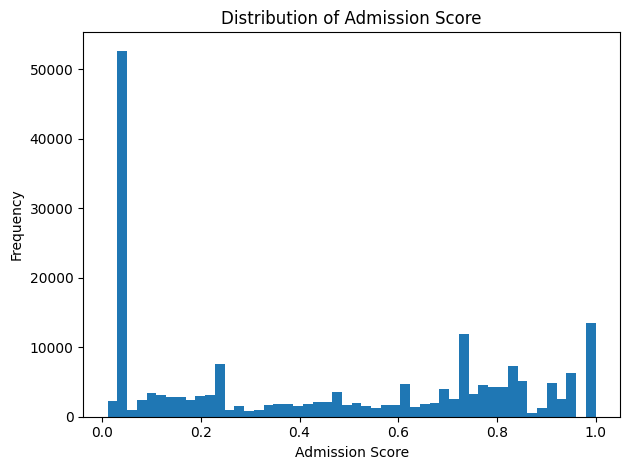

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['admission_score'].dropna(), bins=50)

plt.xlabel('Admission Score')
plt.ylabel('Frequency')
plt.title('Distribution of Admission Score')

plt.tight_layout()
plt.show()

In [ ]:
df.to_parquet("/content/drive/MyDrive/UT Austin/2026 Spring/Sabre/code/one_day_simulation.parquet")

## Data Aggregation



In [ ]:
import pandas as pd


# 1. Group by 'timestamp_hour' and 'cache_key'
# 2. Count 'rq_correlation_id' and name it 'request_count'
# 3. Reset index
df_hourly = df.groupby(['timestamp_hour', 'cache_key'])['rq_correlation_id'].count().reset_index(name='request_count')


df_hourly = (
    df_hourly
    .set_index('timestamp_hour')
    .groupby('cache_key', group_keys=False)
    .apply(lambda x: x.asfreq('h').assign(cache_key=x.name))
    .fillna({'request_count': 0})
    .reset_index()
)

# 4. Sort by 'timestamp_hour'
df_hourly = df_hourly.sort_values(by='timestamp_hour', ascending=True)

# 5. Inspect the aggregated data
print("Aggregated Hourly Data:")
print(df_hourly.head())
print(f'\nShape of aggregated data: {df_hourly.shape}')

Aggregated Hourly Data:
                  timestamp_hour                     cache_key  request_count
15664  2026-02-07 00:00:00+00:00  CQ-LGA-2026-02-18-2026-02-20            2.0
104869 2026-02-07 00:00:00+00:00  RW-LGA-2026-08-15-2026-08-20            1.0
115929 2026-02-07 00:00:00+00:00  UA-LGA-2026-02-23-2026-02-26            2.0
88545  2026-02-07 00:00:00+00:00  PE-DFW-2026-02-07-2026-02-10            6.0
135348 2026-02-07 00:00:00+00:00  YO-JFK-2026-05-09-2026-05-10            2.0

Shape of aggregated data: (139489, 3)


/tmp/ipykernel_4710/573517486.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.asfreq('h').assign(cache_key=x.name))


In [ ]:
df_hourly.columns

Index(['timestamp_hour', 'cache_key', 'request_count',
       'next_hour_request_count', 'hour_of_day'],
      dtype='object')

In [ ]:
import gc

gc.collect()

0

In [ ]:
df_hourly = df_hourly.merge(
    df[['cache_key', 'lead_time']],
    on='cache_key',
    how='left'
)

# bucket（推荐）
df_hourly['lead_time_bucket'] = pd.cut(
    df_hourly['lead_time'],
    bins=[-1, 1, 3, 7, 30, 365],
    labels=['same_day','short','mid','long','very_long']
)


## Model Preparation




In [ ]:
# 1. Create the target variable: next_hour_request_count, target
import holidays
df_hourly['next_hour_request_count'] = df_hourly.groupby('cache_key')['request_count'].shift(-1)

df_hourly['next_hour_request_count']= df_hourly['next_hour_request_count'].fillna(0)


# 3. Generate time-based features
df_hourly['hour_of_day'] = df_hourly['timestamp_hour'].dt.hour
df_hourly['day_of_week'] = df_hourly['timestamp_hour'].dt.dayofweek

# 4. Create lag features (lag_1h, lag_2h) to capture AR patterns
df_hourly['lag_1h'] = df_hourly.groupby('cache_key')['request_count'].shift(1)
df_hourly['lag_2h'] = df_hourly.groupby('cache_key')['request_count'].shift(2)

df_hourly['last_request_time'] = (
    df_hourly.groupby('cache_key')['timestamp_hour']
    .transform(lambda x: x.where(df_hourly.loc[x.index, 'request_count'] > 0).ffill())
)


df_hourly['request_time_gap'] = (
    (df_hourly['timestamp_hour'] - df_hourly['last_request_time'])
    .dt.total_seconds() / 3600
)

# 5. Handle missing values: Fill lags with 0 (assuming no activity) and drop rows where target is NaN (last hours of the dataset)
df_hourly[['lag_1h', 'lag_2h']] = df_hourly[['lag_1h', 'lag_2h']].fillna(0)

df_hourly['past_3h'] = df_hourly.groupby('cache_key')['request_count'].rolling(3).sum().reset_index(level=0, drop=True)
df_hourly['past_6h'] = df_hourly.groupby('cache_key')['request_count'].rolling(6).sum().reset_index(level=0, drop=True)
df_hourly['past_3h'] = df_hourly['past_3h'].fillna(0)
df_hourly['past_6h'] = df_hourly['past_6h'].fillna(0)

df_hourly['weekday'] = df_hourly['timestamp_hour'].dt.weekday
df_hourly['is_weekend'] = df_hourly['weekday'] >= 5

# 把 lead_time merge 到 df_hourly（按 cache_key）
df_hourly = df_hourly.merge(
    df[['cache_key', 'lead_time']],
    on='cache_key',
    how='left'
)

# bucket（推荐）
df_hourly['lead_time_bucket'] = pd.cut(
    df_hourly['lead_time'],
    bins=[-1, 1, 3, 7, 30, 365],
    labels=['same_day','short','mid','long','very_long']
)


us_holidays = holidays.US()

df_hourly['is_holiday'] = df_hourly['timestamp_hour'].dt.date.isin(us_holidays)

df_hourly['leadtime_x_recent'] = df_hourly['lead_time'] * df_hourly['lag_1h']

df_hourly['recent_and_close'] = (
    (df_hourly['lag_1h'] > 0) & (df_hourly['lead_time'] <= 1)
).astype(int)


# df_hourly['next_3h_request'] = df_hourly.groupby('cache_key')['request_count']

# Inspect results
print(f"Original shape: {df_hourly.shape}")


KeyboardInterrupt: 

In [ ]:
df_hourly[df_hourly['cache_key']=='HX-DFW-2026-02-21-2026-02-22-14'].head()

,timestamp_hour,cache_key,request_count,next_hour_request_count,hour_of_day,day_of_week,lag_1h,lag_2h,last_request_time,request_time_gap,past_3h,past_6h,weekday,is_weekend,lead_time,lead_time_bucket,is_holiday,leadtime_x_recent,recent_and_close
94493,2026-02-07 03:00:00+00:00,HX-DFW-2026-02-21-2026-02-22-14,40.0,136.0,3,5,0.0,0.0,2026-02-07 03:00:00+00:00,0.0,0.0,0.0,5,True,14,long,False,0.0,0
107340,2026-02-07 04:00:00+00:00,HX-DFW-2026-02-21-2026-02-22-14,136.0,0.0,4,5,40.0,0.0,2026-02-07 04:00:00+00:00,0.0,0.0,0.0,5,True,14,long,False,560.0,0


In [ ]:
mask = df_hourly[df_hourly['last_request_time'].isna()]
mask.head()

,timestamp_hour,cache_key,request_count,next_hour_request_count,hour_of_day,day_of_week,lag_1h,lag_2h,last_request_time,request_time_gap,past_3h,past_6h,weekday,is_weekend,lead_time,lead_time_bucket,is_holiday,leadtime_x_recent,recent_and_close


In [ ]:
import matplotlib.pyplot as plt

# ===== 1. next_hour_request_count 分布（bar chart）=====

plt.figure()
plt.figsize = (20, 6)
df_hourly['next_hour_request_count'].value_counts().sort_index().plot(kind='bar')
plt.title('Next Hour Request Count Distribution')
plt.xlabel('next_hour_request_count')
plt.ylabel('Frequency')
plt.show()



# ===== 3. lead_time vs request_count（关系）=====
plt.figure()
plt.scatter(df_hourly['lead_time'], df_hourly['request_count'], alpha=0.1)
plt.title('Lead Time vs Request Count')
plt.xlabel('lead_time')
plt.ylabel('request_count')
plt.show()


plt.figure()
df_hourly.groupby('lead_time_bucket')['request_count'].mean().plot(kind='bar')
plt.title('Avg Request Count by Lead Time Bucket')
plt.xlabel('lead_time_bucket')
plt.ylabel('avg_request_count')
plt.show()

In [ ]:


df_plot = df_hourly.copy()
df_plot['label'] = (df_plot['next_hour_request_count'] > 0).astype(int)

# lead_time bucket
df_plot['lead_time_bucket'] = pd.cut(
    df_plot['lead_time'],
    bins=[-1, 1, 3, 7, 30, 365],
    labels=['same_day','short','mid','long','very_long']
)

# 统计数量
count_df = (
    df_plot.groupby(['lead_time_bucket', 'label'])
    .size()
    .unstack(fill_value=0)
)

# 画图
count_df.plot(kind='bar')

plt.title('Label Distribution by Lead Time Bucket')
plt.xlabel('lead_time_bucket')
plt.ylabel('Count')
plt.legend(title='label (0/1)')
plt.xticks(rotation=0)
plt.show()

## Modeling

In [ ]:
df_ml = df_hourly.copy()
df_ml['label'] = (df_ml['next_hour_request_count'] > 0).astype(int)

In [ ]:
import numpy as np


features = [
    'lag_1h', 'lag_2h',
    'past_3h', 'past_6h',
    'request_time_gap',
    'hour_of_day', 'day_of_week',
    'is_weekend', 'is_holiday',
    'lead_time','leadtime_x_recent',
    'recent_and_close', 'lead_time_bucket'
]

X = df_ml[features]
y = df_ml['label']
time = df_ml['timestamp_hour']

# 去掉 NaN
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]
time = time[mask]

# ===== time split =====
split_time = time.quantile(0.8)

X_train = X[time <= split_time]
X_test  = X[time > split_time]

y_train = y[time <= split_time]
y_test  = y[time > split_time]

### XGBoost

In [ ]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

model_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    enable_categorical = True,
    random_state=42
)

model_xgb.fit(X_train, y_train)

y_pred_prob = model_xgb.predict_proba(X_test)[:, 1]

threshold = 0.01
y_pred = (y_pred_prob > threshold).astype(int)


precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Threshold: {threshold}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")

# 预测概率
y_pred_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

# AUC
auc_xgb = roc_auc_score(y_test, y_pred_prob_xgb)
print("XGBoost AUC:", auc_xgb)

Threshold: 0.01
Precision: 0.3237
Recall: 0.8727
F1: 0.4722
XGBoost AUC: 0.6575203240182177


In [ ]:
model_xgb.save_model("/content/drive/MyDrive/UT Austin/2026 Spring/Sabre/code/xgb_model.json")

# ===== 3. 加载模型 =====
# loaded_model = xgb.XGBClassifier()
# loaded_model.load_model("xgb_model.json")

# # ===== 4. 用加载的模型预测 =====
# y_pred_prob = loaded_model.predict_proba(X_test)[:, 1]

In [ ]:
#feature importance

feature_importance = model_xgb.feature_importances_
feature_names = X_train.columns
#print feature importance in order
for score, name in sorted(zip(feature_importance, feature_names), reverse=True):
    print(name, score)

lead_time 0.19347046
hour_of_day 0.15756269
lead_time_bucket 0.12275499
request_time_gap 0.11754792
recent_and_close 0.08847164
past_6h 0.08134925
lag_2h 0.06693511
leadtime_x_recent 0.05846305
past_3h 0.057956062
lag_1h 0.055488773
is_weekend 0.0
is_holiday 0.0
day_of_week 0.0


### LightGBM

In [ ]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

model_lgb = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    # class_weight='balanced'
)

model_lgb.fit(X_train, y_train)

y_pred_prob = model_lgb.predict_proba(X_test)[:, 1]

threshold = 0.2
y_pred = (y_pred_prob > threshold).astype(int)


precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Threshold: {threshold}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")

y_pred_prob_lgb = model_lgb.predict_proba(X_test)[:, 1]

# AUC
auc_lgb = roc_auc_score(y_test, y_pred_prob_lgb)
print("XGBoost AUC:", auc_lgb)

[LightGBM] [Info] Number of positive: 17901, number of negative: 100041
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004517 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 831
[LightGBM] [Info] Number of data points in the train set: 117942, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.151778 -> initscore=-1.720724
[LightGBM] [Info] Start training from score -1.720724
Threshold: 0.2
Precision: 0.4614
Recall: 0.4439
F1: 0.4525
XGBoost AUC: 0.6735296155100597


### Catboost

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

model_cat = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    verbose=0,
    # auto_class_weights='Balanced',
    random_state=42
)

categorical_features = ['lead_time_bucket']
model_cat.fit(X_train, y_train)

y_pred_prob = model_cat.predict_proba(X_test)[:, 1]

threshold = 0.1
y_pred = (y_pred_prob > threshold).astype(int)


precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Threshold: {threshold}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")

y_pred_prob_cat = model_cat.predict_proba(X_test)[:, 1]

auc_cat = roc_auc_score(y_test, y_pred_prob_cat)
print("CatBoost AUC:", auc_cat)

TypeError: CatBoostClassifier.__init__() got an unexpected keyword argument 'categorical_features'

### bucket-wised modeling

In [ ]:

results = {}

# ===== 按 bucket 分开建模 =====
for bucket in df_ml['lead_time_bucket'].dropna().unique():

    df_b = df_ml[df_ml['lead_time_bucket'] == bucket]

    X = df_b[features]
    y = df_b['label']
    time = df_b['timestamp_hour']

    # 去 NaN
    mask = X.notna().all(axis=1) & y.notna()
    X = X[mask]
    y = y[mask]
    time = time[mask]

    # time split
    split_time = time.quantile(0.8)

    X_train = X[time <= split_time]
    X_test  = X[time > split_time]
    y_train = y[time <= split_time]
    y_test  = y[time > split_time]

    # model
    model = xgb.XGBClassifier(
      n_estimators=1000,
      max_depth=10,
      learning_rate=0.05,
      # scale_pos_weight=scale_pos_weight,
      subsample=0.8,
      colsample_bytree=0.8,
      eval_metric='logloss',
      enable_categorical = True,
      random_state=42
    )

    model.fit(X_train, y_train)

    # predict
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # if bucket in ['same_day','short','mid']:
    #     threshold = 0.3
    # elif bucket == 'long':
    #     threshold = 0.05
    # else:
    #   threshold = 0.001
    # y_pred = (y_pred_prob > threshold).astype(int)


    # precision = precision_score(y_test, y_pred)
    # recall = recall_score(y_test, y_pred)
    # f1 = f1_score(y_test, y_pred)

    # print(f"Threshold: {threshold}")
    # print(f"Precision: {precision:.4f}")
    # print(f"Recall: {recall:.4f}")
    # print(f"F1: {f1:.4f}")

    # eval
    auc = roc_auc_score(y_test, y_pred_prob)

    results[bucket] = auc
    print(f"{bucket} AUC: {auc:.4f}")

# ===== 总结 =====
print("\nAUC by bucket:")
print(results)

long AUC: 0.6813
very_long AUC: 0.6811
same_day AUC: 0.6397
short AUC: 0.6291
mid AUC: 0.7745

AUC by bucket:
{'long': np.float64(0.6813403040039081), 'very_long': np.float64(0.6811422545677192), 'same_day': np.float64(0.6397002293363186), 'short': np.float64(0.6290773346109315), 'mid': np.float64(0.7745454372181777)}


In [ ]:
# ===== XGBoost Grid Search（只针对 bucket = same_day）=====

import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

# ===== 1. 筛选 same_day =====
df_b = df_hourly.copy()
df_b['label'] = (df_b['next_hour_request_count'] > 0).astype(int)

df_b = df_b[df_b['lead_time_bucket'] == 'same_day']



X = df_b[features]
y = df_b['label']
time = df_b['timestamp_hour']

# 去 NaN
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]
time = time[mask]

# ===== 3. time-based split =====
split_time = time.quantile(0.8)

X_train = X[time <= split_time]
X_test  = X[time > split_time]
y_train = y[time <= split_time]
y_test  = y[time > split_time]

# ===== 4. model =====
model = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    enable_categorical = True
)

# ===== 5. param grid =====
param_grid = {
    'max_depth': [3, 5, 7,9],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200,500],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

# ===== 6. grid search =====
grid = GridSearchCV(
    model,
    param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

# ===== 7. evaluate on test =====
best_model = grid.best_estimator_
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_prob)
print("Test AUC:", auc)

Fitting 3 folds for each of 144 candidates, totalling 432 fits
Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.9}
Best CV AUC: 0.6421139797549925
Test AUC: 0.6967006855430844


## LSTM

In [ ]:
df_hourly.to_parquet("/content/drive/MyDrive/UT Austin/2026 Spring/Sabre/code/three_month_modified_hourly.parquet")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ===== 1. 数据准备 =====
df_model = df_hourly.copy()
df_model['label'] = (df_model['next_hour_request_count'] > 0).astype(int)

# df_model = df_model[df_model['lead_time_bucket'] == 'same_day']
df_model = df_model.sort_values(['timestamp_hour', 'cache_key'])

# features = [
#     'request_count',
#     'lag_1h', 'lag_2h',
#     'past_3h', 'past_6h',
#     'request_time_gap',
#     'hour_of_day', 'day_of_week',
#     'is_weekend', 'is_holiday',
#     'lead_time'
# ]

# df_model = df_model.dropna(subset=features + ['label'])

# ===== 2. 时间切分（关键🔥）=====
split_time = df_model['timestamp_hour'].quantile(0.8)

train_df = df_model[df_model['timestamp_hour'] <= split_time]
test_df  = df_model[df_model['timestamp_hour'] > split_time]

# ===== 3. 标准化（只fit train🔥）=====
scaler = StandardScaler()
train_df[features] = scaler.fit_transform(train_df[features])
test_df[features]  = scaler.transform(test_df[features])

# ===== 4. 构造序列 =====
SEQ_LEN = 3

def build_sequences(df):
    X_list, y_list = [], []

    for key, group in df.groupby('cache_key'):
        group = group.sort_values('timestamp_hour')

        data = group[features].values
        labels = group['label'].values

        for i in range(len(group) - SEQ_LEN):
            X_list.append(data[i:i+SEQ_LEN])
            y_list.append(labels[i+SEQ_LEN])

    return np.array(X_list), np.array(y_list)

X_train, y_train = build_sequences(train_df)
X_test, y_test   = build_sequences(test_df)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# ===== 5. class weight =====
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {0: weights[0], 1: weights[1]}

# ===== 6. LSTM模型 =====
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['AUC']
)

# ===== 7. 训练（不再用validation_split❗）=====
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    class_weight=class_weights,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# ===== 8. 评估 =====
y_pred_prob = model.predict(X_test).flatten()

auc = roc_auc_score(y_test, y_pred_prob)
print("LSTM AUC (fixed):", auc)

## TFT